# Análisis de oscilaciones en estrellas roAp

En 1960 Robert Leighton y sus colegas del Observatorio del Monte Wilson en California realizaron un descubrimiento crucial al observar oscilaciones periódicas en la superficie del Sol con un periodo de aproximadamente 5 minutos. Esta observación se publicó en 1962 y marcó el comienzo formal del estudio de las oscilaciones solares.

Años después se desarrollaron teorías para explicar las oscilaciones solares. Las oscilaciones solares nos revelan información crítica sobre la estructura interna del Sol, incluida la distribución de la temperatura, la densidad y la velocidad de rotación en diferentes profundidades. Estos avances sentaron las bases para la **astrosismología**, la rama de la astronomía que estudia las oscilaciones en otras estrellas.

Las estrellas Ap de oscilación rápida (estrellas roAp) son un subtipo de la clase de estrellas A peculiares que exhiben variaciones fotométricas o de velocidad radial rápidas en escalas de tiempo cortas. Las primeras estrellas roAp fueron descubiertas por Kurtz en 1982. El análisis de sus oscilaciones nos permite obtener información valiosa respecto a su estructura interna. 

El objetivo de este trabajo es precisamente analizar las oscilaciones de algunas estrellas de este tipo y determinar elementos que los constituyen, como su temperatura y su gravedad.

## Parte 1: Preparación de datos

Las estrellas asignadas para este análisis son las siguientes:

In [1]:
ids = ["TIC 101624823", "TIC 165052884", "TIC 233200244", "TIC 158271090", "TIC 298052991", "TIC 435263600"]

Tomemos la primera estrella correspondiente:

In [2]:
import lightkurve as lk, astropy, numpy as np, pandas as pd, matplotlib.pyplot as plt

/home/joseangel/Apps/miniconda3/envs/astropy/lib/python3.14/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [4]:
search_result = lk.search_lightcurve(ids[0], mission="TESS")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 22,2020,SPOC,120,101624823,0.0
1,TESS Sector 49,2022,SPOC,20,101624823,0.0
2,TESS Sector 49,2022,SPOC,120,101624823,0.0
3,TESS Sector 22,2020,TESS-SPOC,1800,101624823,0.0
4,TESS Sector 49,2022,TESS-SPOC,600,101624823,0.0
5,TESS Sector 22,2020,QLP,1800,101624823,0.0
6,TESS Sector 49,2022,QLP,600,101624823,0.0
7,TESS Sector 22,2020,CDIPS,1800,101624823,0.0
8,TESS Sector 49,2022,CDIPS,1800,101624823,0.0


Tenemos bases de datos de distintos tipos, autores y con tiempos de exposición distintos. En este caso tomamos aquellos correspondientes a SPOC y con tiempos de exposición de 120s:

In [5]:
search_result = lk.search_lightcurve(ids[0], mission="TESS", author="SPOC",exptime="120")

Ahora descargamos los datos y hacemos un análisis

In [6]:
#Descargamos datos de las curvas de luz y eliminamos posible ruido
lightcurves = [item.download().remove_nans().remove_outliers().flatten() for item in search_result]

Veamos una gráfica de las curvas de luz

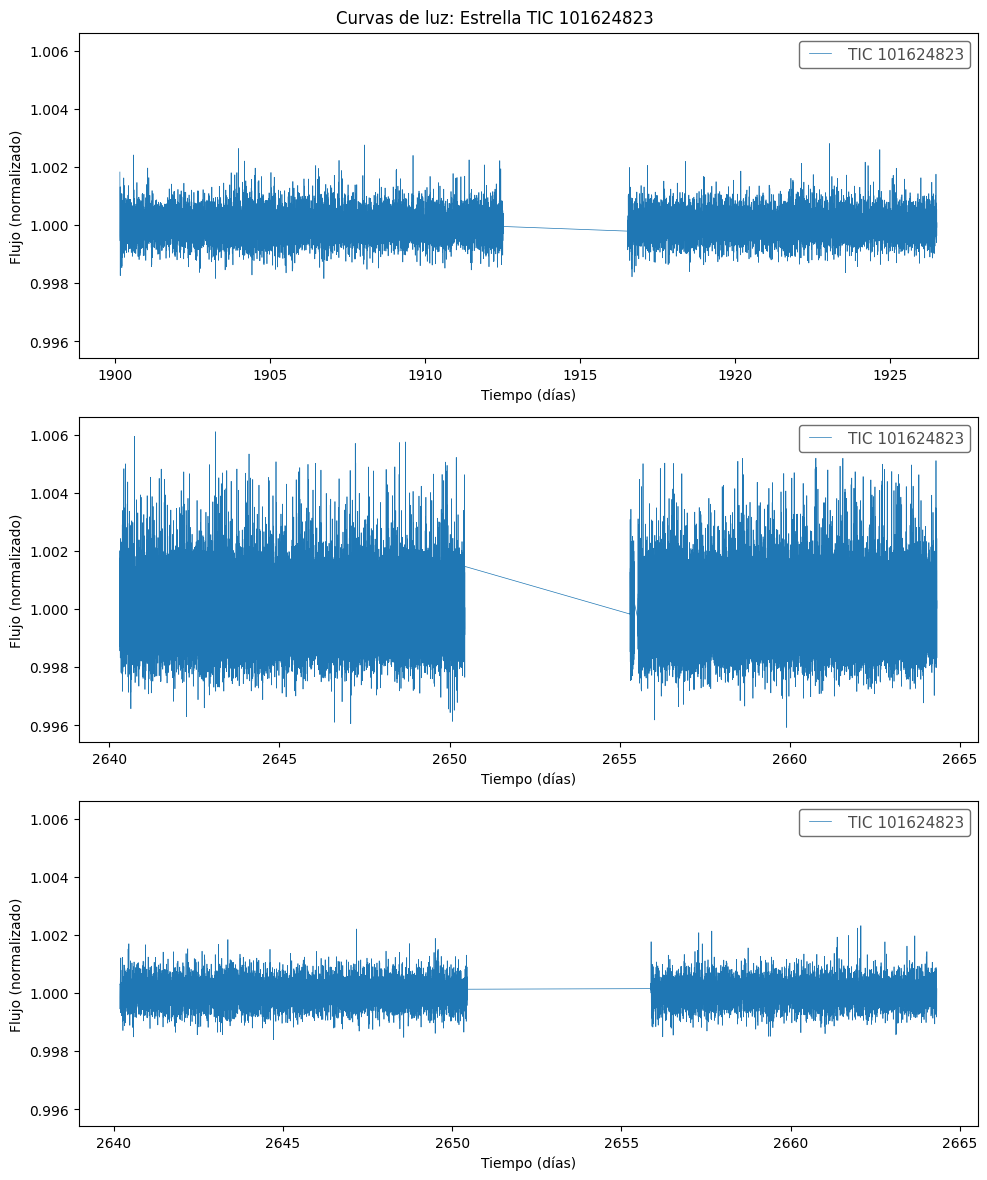

In [7]:
fig, axes = plt.subplots(nrows=len(lightcurves),ncols=1,sharey=True, figsize=(10,12))
for i,lc in enumerate(lightcurves):
    lc.plot(ax=axes[i])
    axes[i].set(xlabel="Tiempo (días)", ylabel="Flujo (normalizado)")

fig.suptitle(f'Curvas de luz: Estrella {ids[0]}')
plt.tight_layout()
plt.show()

Para explorar cosas como la frecuencia y el periodo realizamos una transformada de Fourier específica: el periodograma.

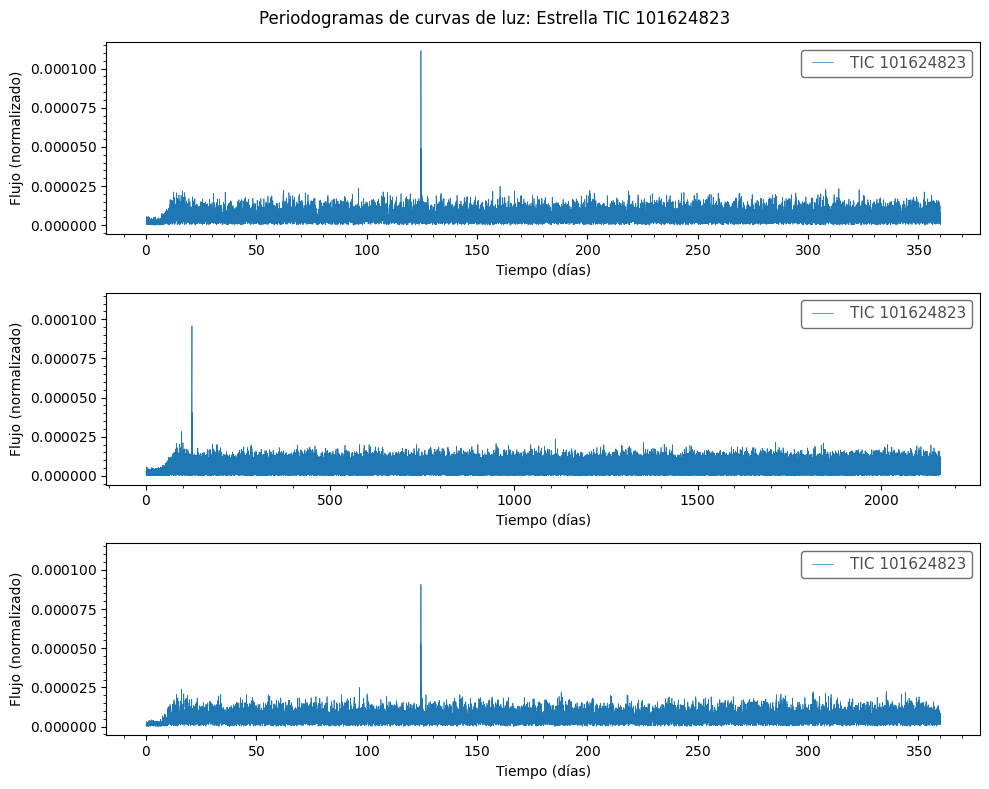

In [8]:
#plt.style.use('dark_background')
fig, axes = plt.subplots(nrows=len(lightcurves), ncols=1, sharey=True, figsize=(10,8))
for i,lc in enumerate(lightcurves):
    lc.to_periodogram().plot(ax=axes[i])
    axes[i].set(xlabel="Tiempo (días)", ylabel="Flujo (normalizado)")

fig.suptitle(f'Periodogramas de curvas de luz: Estrella {ids[0]}')
plt.tight_layout()
plt.show()

Ahora que tenemos una idea de qué es lo que buscamos, podemos empezar a generalizar este procedimiento para múltiples estrellas.

## Parte 2: Generalización a múltiples ID's

In [ ]:
# Paqueterías necesarias y utilidades modulares
from scipy.signal import find_peaks
from astroquery.mast import Catalogs
import numpy as np
import pandas as pd
from analysis_utils import get_star_params_professional, calculate_large_separation, estimate_snr

In [ ]:
# DataFrame estructurado para almacenamiento científico de resultados
results_df = pd.DataFrame(columns=[
    'TIC', 'Teff', 'e_Teff', 'logg', 'e_logg', 
    'DominantFreq_d_1', 'DeltaNu_uHz', 'SNR_Max'
])
valid_ids = []

In [ ]:
# Nota: La función get_star_params ha sido mejorada y movida a analysis_utils.py
# para cumplir con estándares de modularidad y manejo de errores.

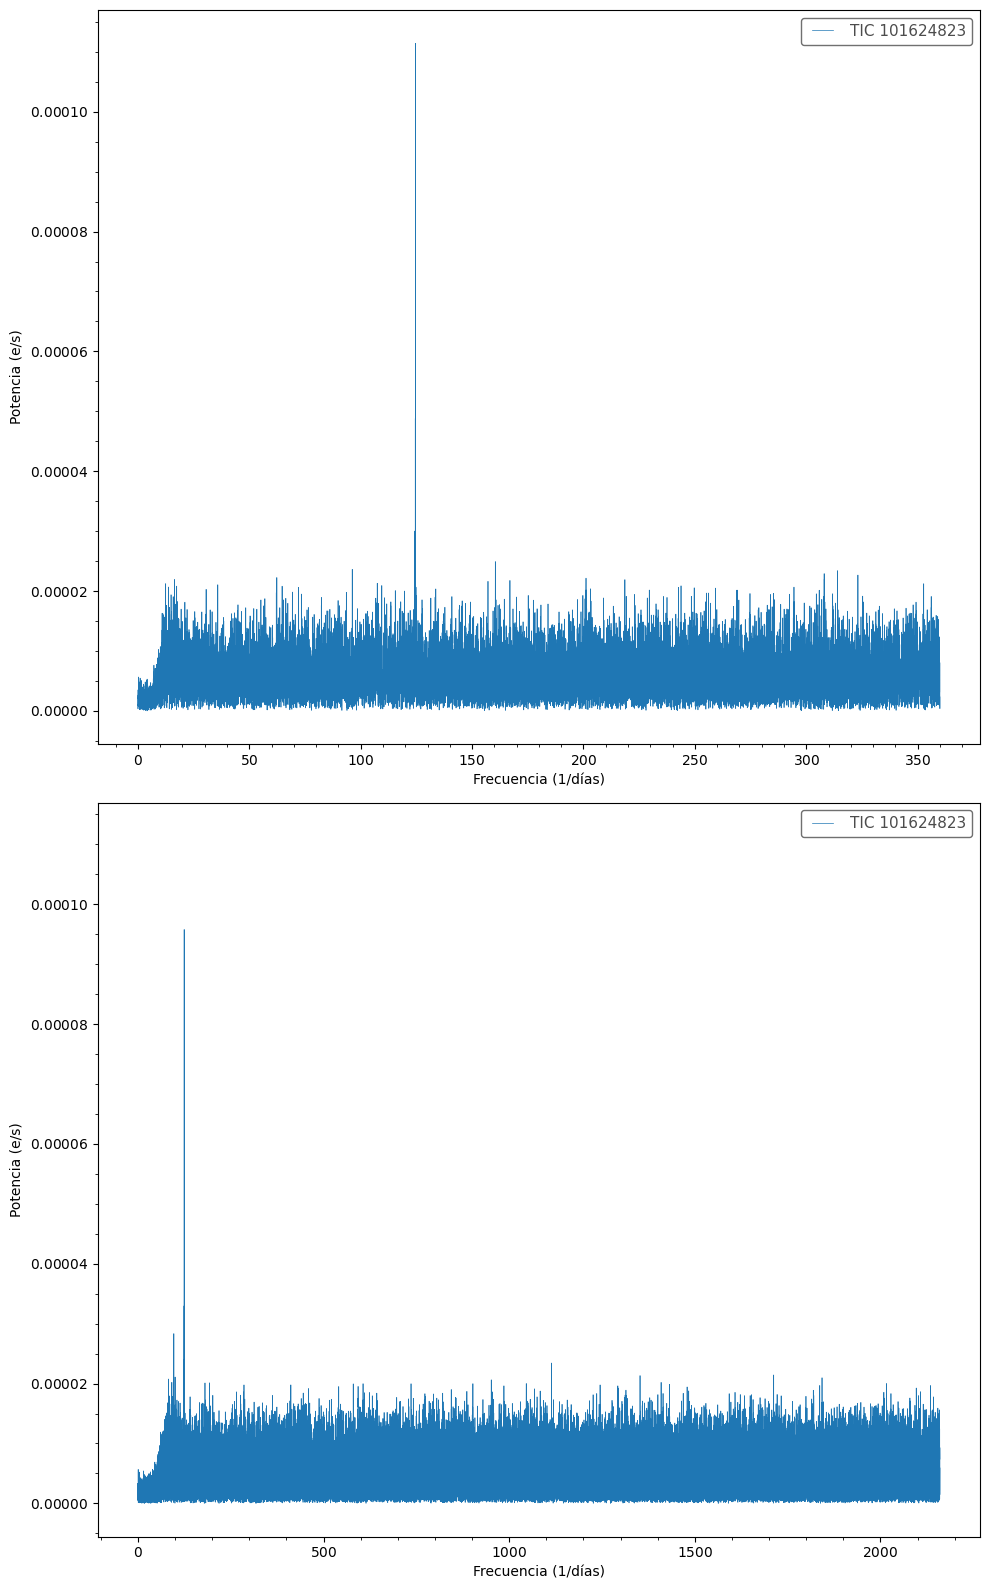

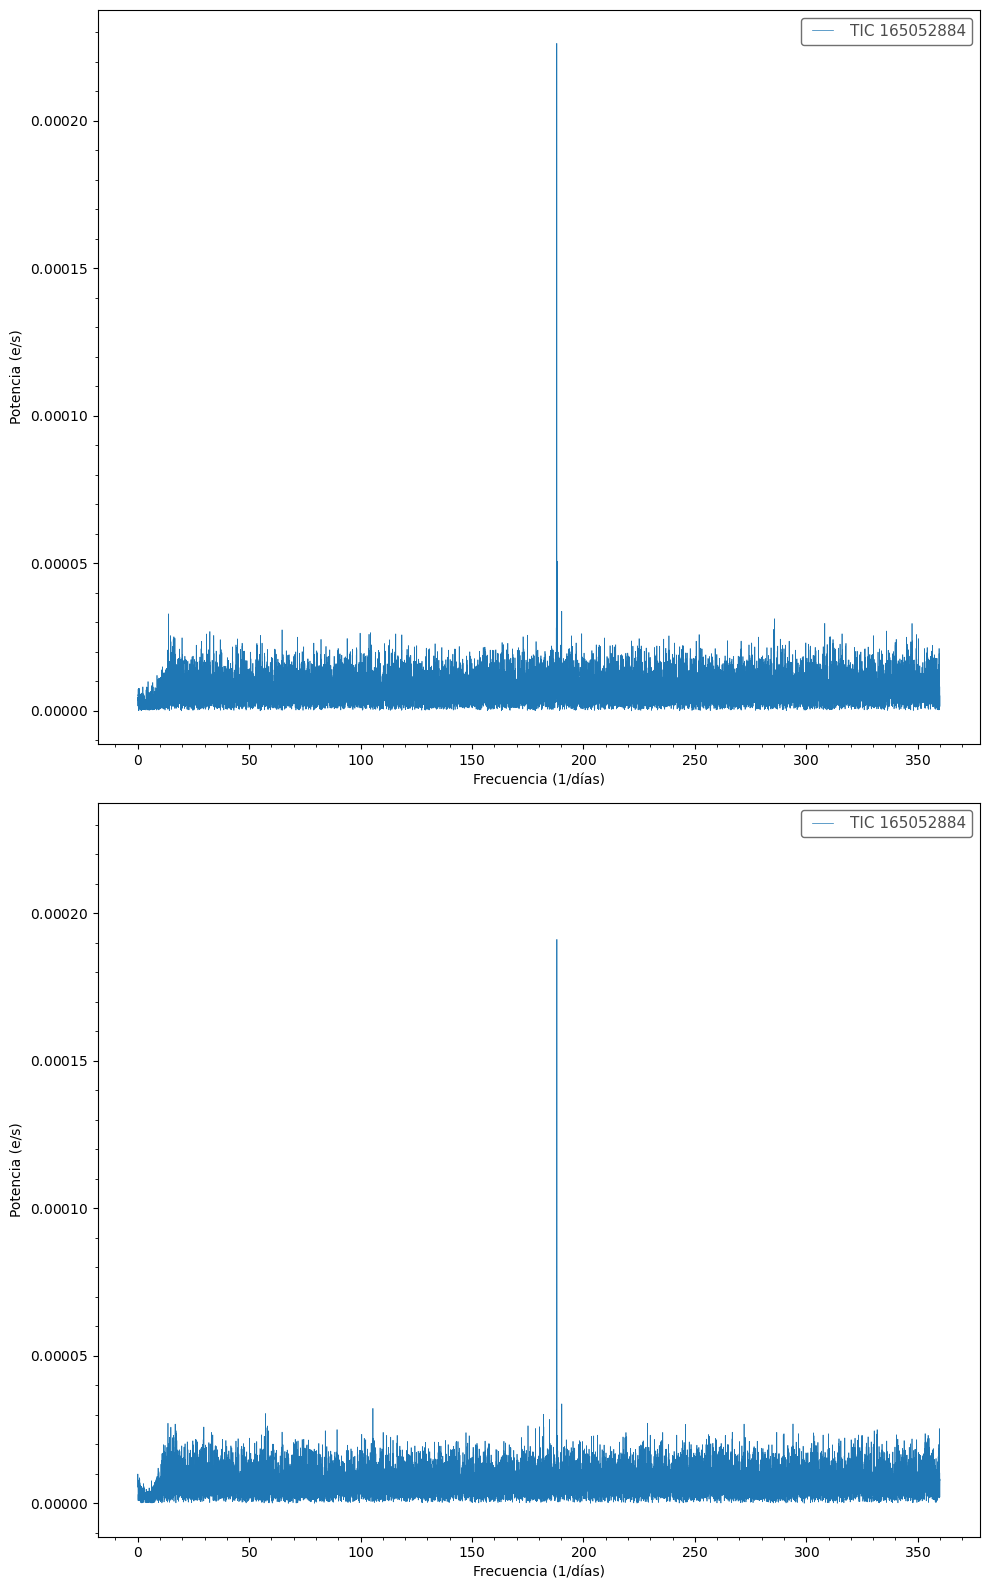

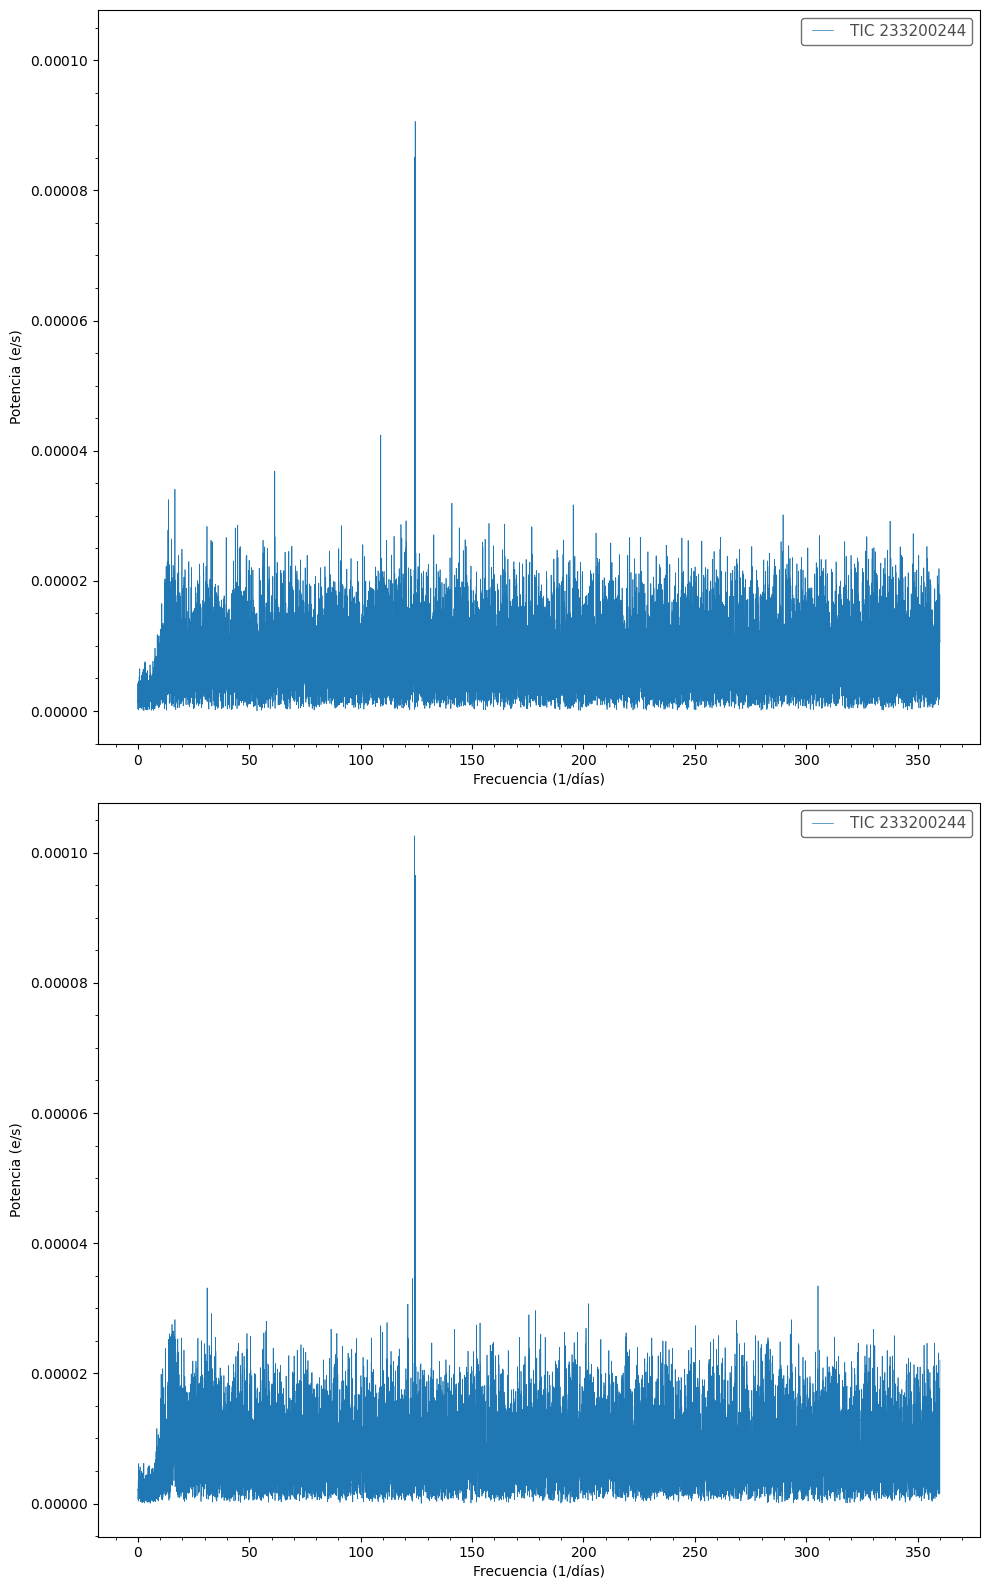

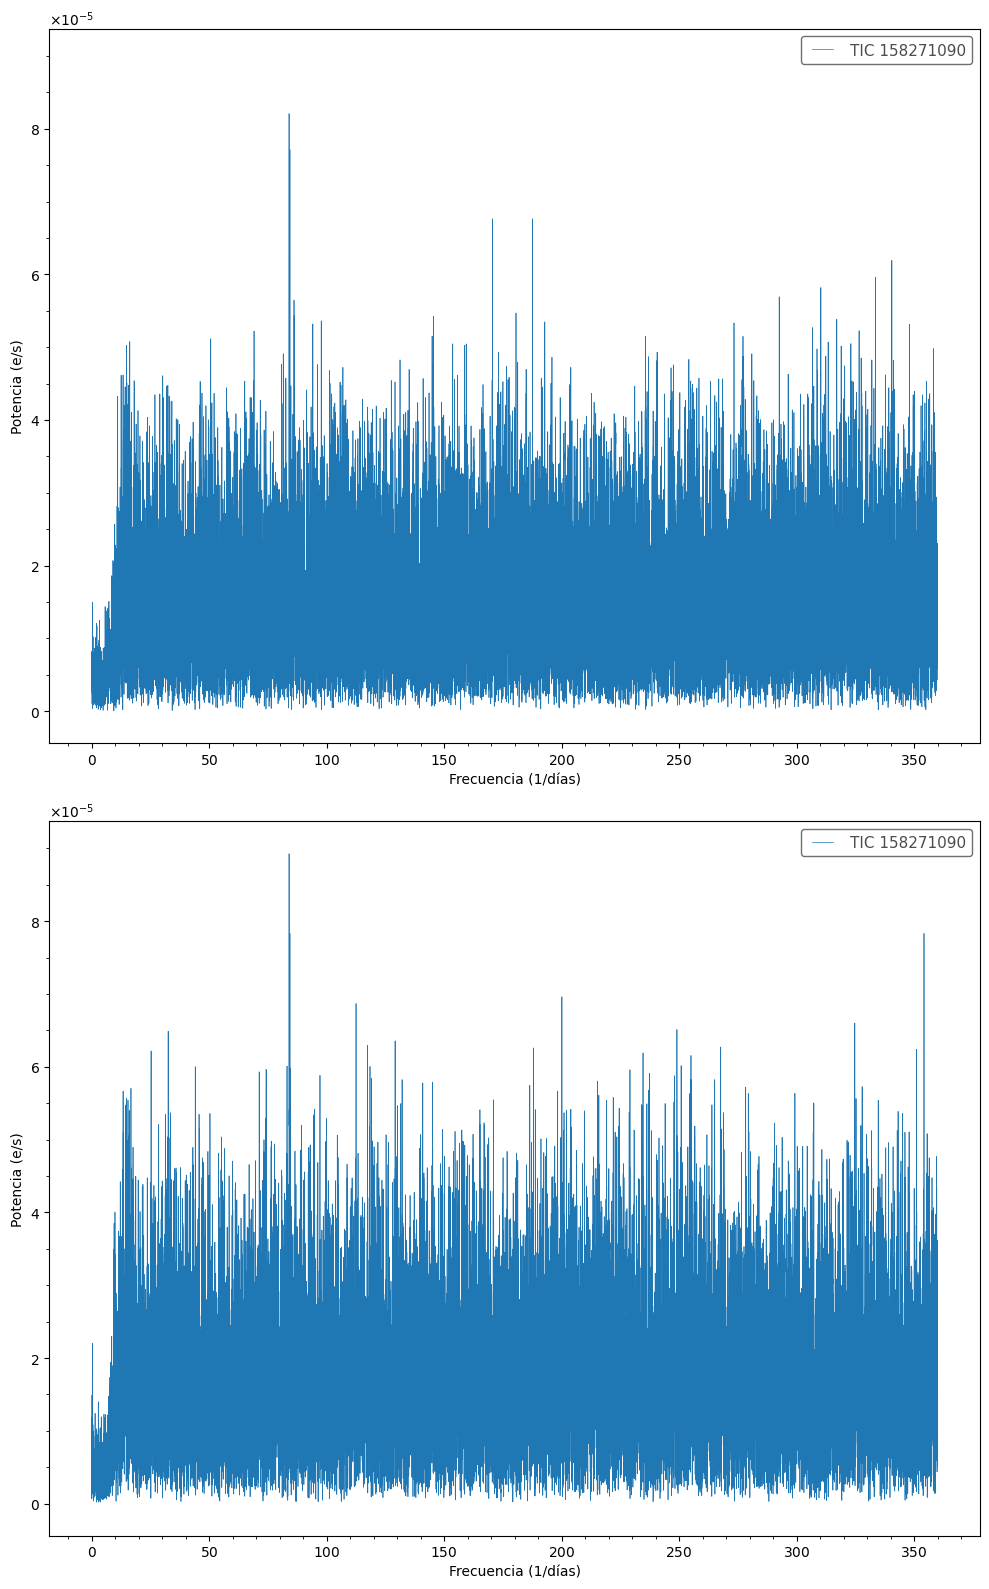

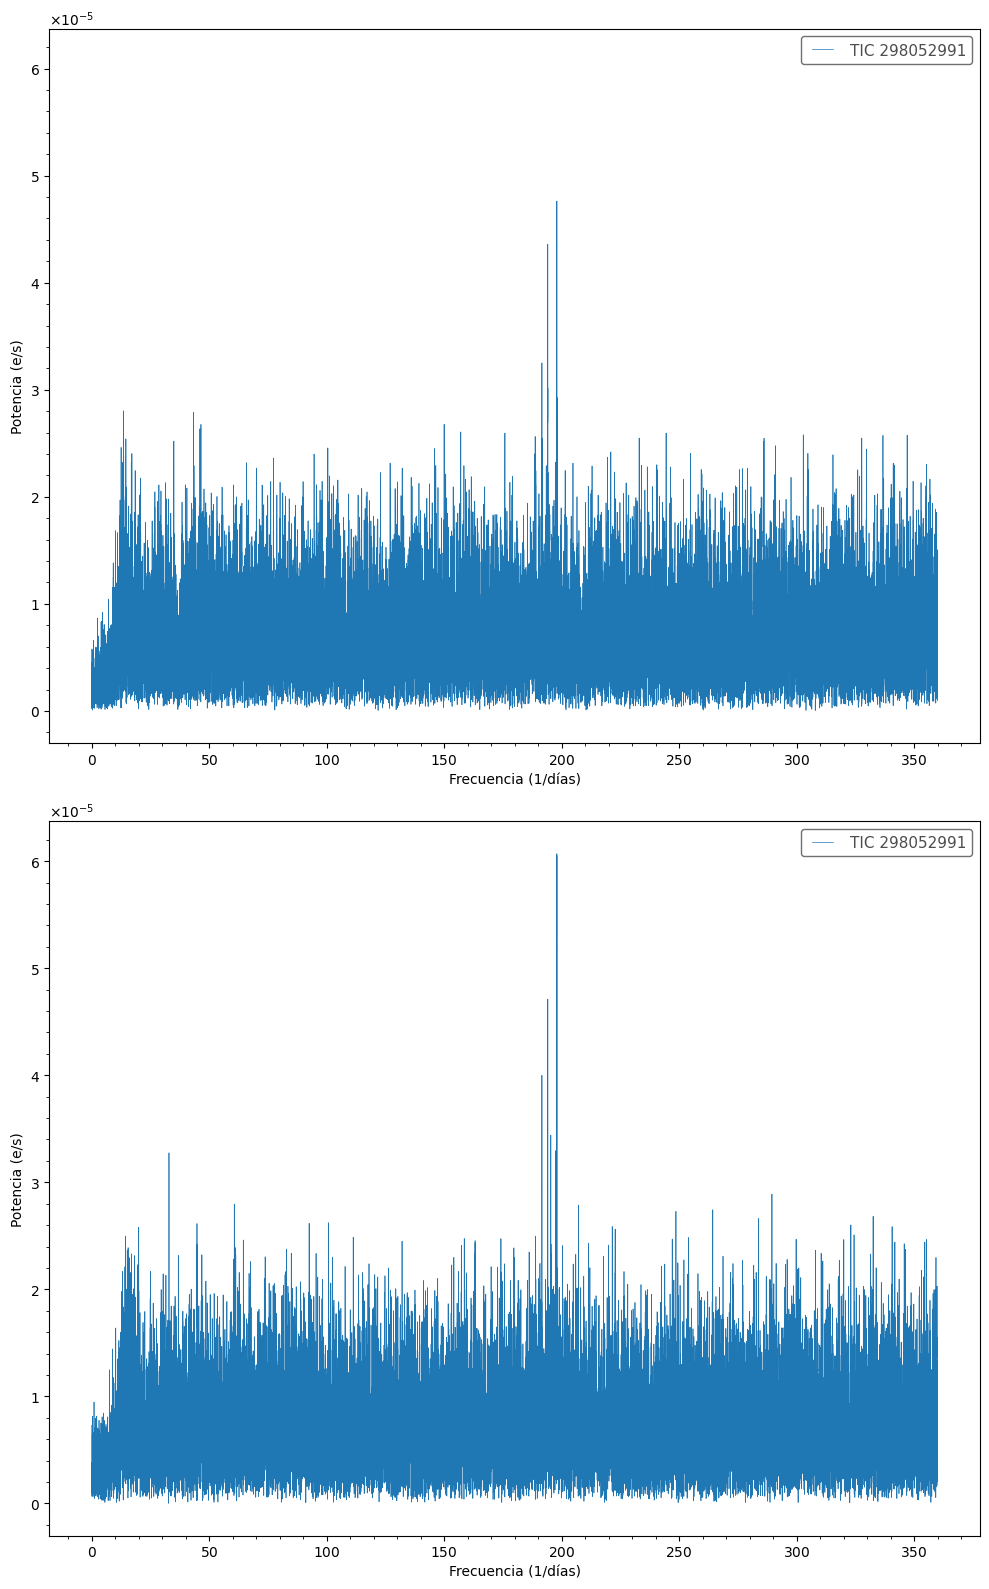

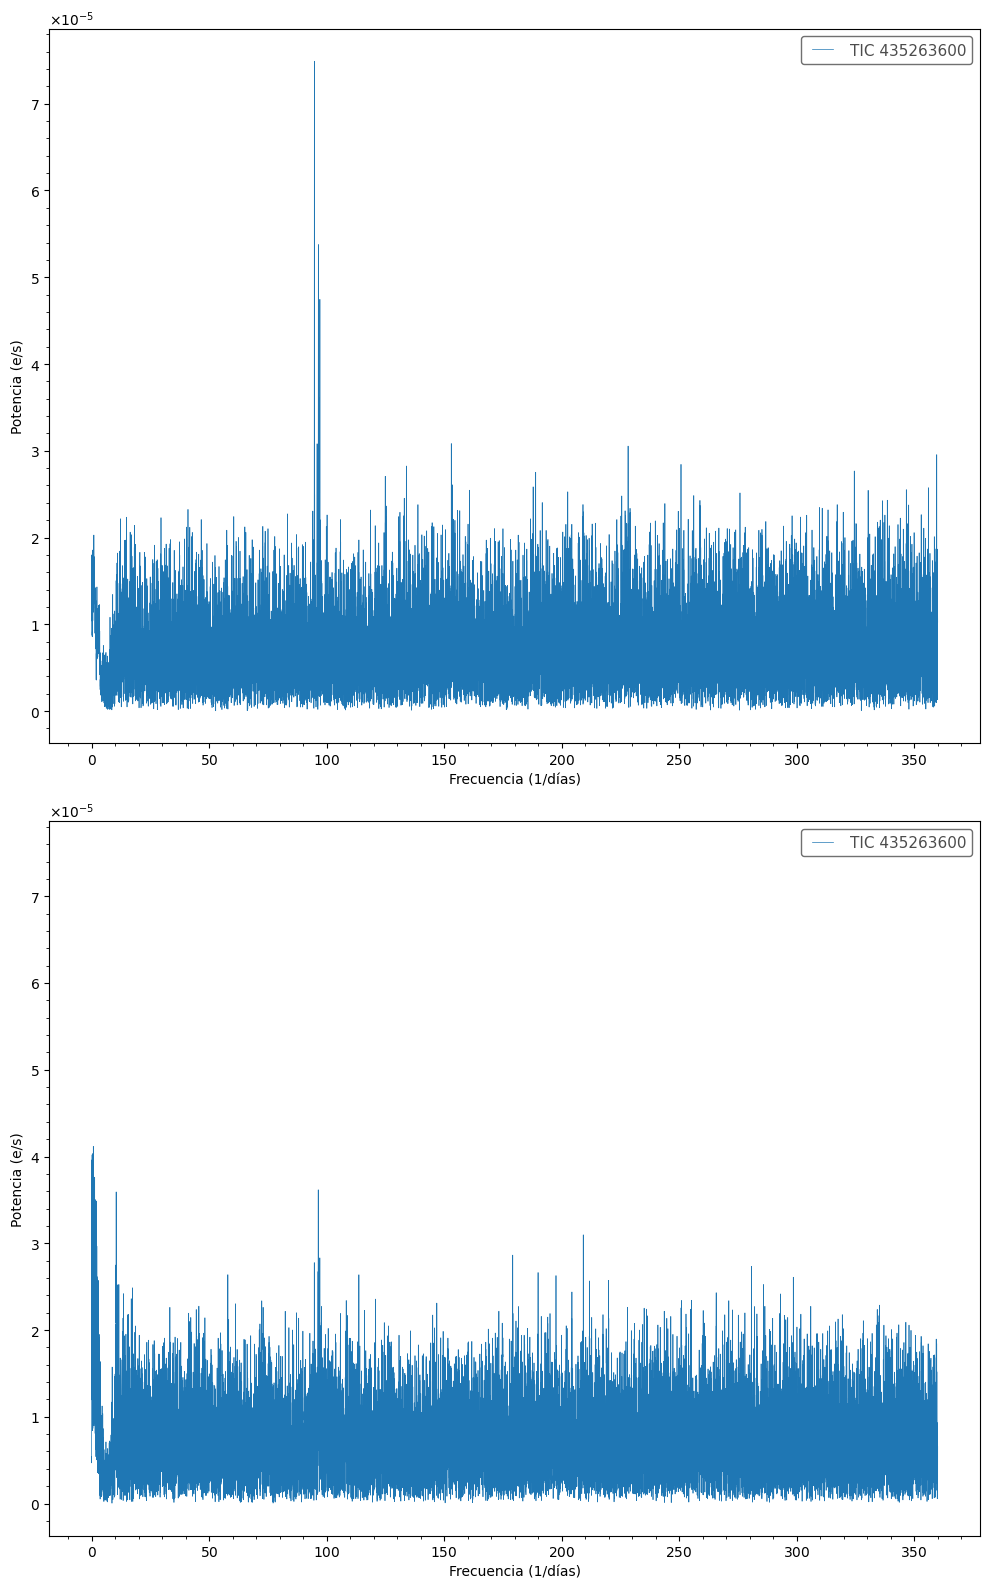

Frecuencias promedio: [np.float64(118.93245313509246), np.float64(188.08759539177822), np.float64(124.33179168854527), np.float64(194.54899906845546), np.float64(0.41532984023543423)]
Períodos promedio: [np.float64(0.008494930825892545), np.float64(0.0053166721091468215), np.float64(0.008043001797708858), np.float64(0.005141015366191619), np.float64(3.7902637993513144)]
Temperaturas efectivas: [np.float64(6776.0), np.float64(6898.0), np.float64(8218.0), np.float64(7386.98), np.float64(7596.0), np.float64(nan)]
Gravedad superficial: [np.float64(3.83447), np.float64(4.17896), np.float64(4.06512), np.float64(3.73299), np.float64(4.30573), np.float64(nan)]


In [ ]:
for id in ids:
    print(f"Analyzing {id}...")
    search_result = lk.search_lightcurve(id, mission="TESS", author="SPOC", exptime="120")
    
    if len(search_result) == 0:
        print(f"No SPOC 120s data found for {id}")
        continue
        
    # Usamos los primeros dos sectores por eficiencia en la visualización
    lightcurves = [item.download().remove_nans().remove_outliers().flatten() for item in search_result[0:2]]
    
    fig, axes = plt.subplots(nrows=len(lightcurves), ncols=1, sharey=True, figsize=(10, 8 * len(lightcurves)))

    last_pg = None
    for i, lc in enumerate(lightcurves):
        # Lomb-Scargle para obtener amplitudes reales en partes-por-millón (ppm)
        pg = lc.to_periodogram(method='lombscargle', normalization='amplitude', oversample_factor=5)
        pg.plot(ax=axes[i], view='amplitude', color='black', lw=0.5)
        axes[i].set(xlabel="Frequency (d$^{-1}$)", ylabel="Amplitude (ppm)")
        last_pg = pg
    
    # Análisis de señales (Seismology)
    frequencies = last_pg.frequency.value
    amplitude = last_pg.power.value * 1e6 # Convert to ppm
    
    peaks_idx = estimate_snr(amplitude)
    peak_freqs = frequencies[peaks_idx]
    peak_amps = amplitude[peaks_idx]
    
    delta_nu = calculate_large_separation(peak_freqs)
    
    # Obtener parámetros físicos con errores (GDR3 style)
    teff, e_teff, logg, e_logg = get_star_params_professional(id)
    
    # Guardar en DataFrame
    dom_freq = peak_freqs[np.argmax(peak_amps)] if len(peak_freqs) > 0 else np.nan
    snr_max = np.max(peak_amps) / np.median(amplitude) if len(peak_freqs) > 0 else 0
    
    results_df = pd.concat([results_df, pd.DataFrame([{
        'TIC': id, 'Teff': teff, 'e_Teff': e_teff, 
        'logg': logg, 'e_logg': e_logg, 
        'DominantFreq_d_1': dom_freq, 
        'DeltaNu_uHz': delta_nu,
        'SNR_Max': snr_max
    }])], ignore_index=True)

    plt.tight_layout()
    plt.show()

# Resumen de resultados científicos
print("\n--- RESUMEN DE ANÁLISIS ASTROFÍSICO ---")
display(results_df)

## Parte III: Diagrama HR

Una vez obtenido la frecuencia y el periodo de estas estrellas, podemos usar datos conocidos de estas estrellas para hallar su tenperatura y gravedad, y crear un diagrama HR de estas estrellas.

In [13]:
from adjustText import adjust_text
import os
from pathlib import Path
# Si el notebook está en la carpeta 'main' y 'sequences' es hermana, usar ../sequences
candidate = Path.cwd().parent / "sequences"
if candidate.is_dir():
    base_dir = str(candidate) + os.sep
else:
    # fallback a la ruta absoluta anterior si no se encuentra
    base_dir = "/home/joseangel/Downloads/sequences/"
    print(f"Advertencia: carpeta {candidate} no encontrada. Usando {base_dir}")

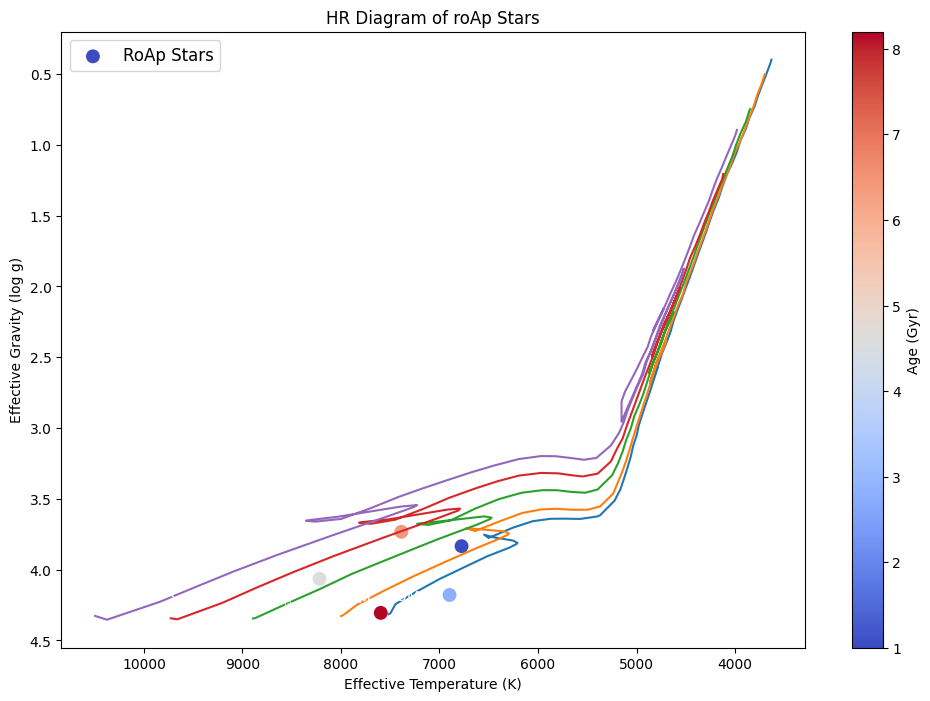

In [ ]:
# Carga de modelos evolutivos y visualización profesional del Diagrama HR
def load_track(file_path):
    cols = ['age/yr', 'logL', 'logTeff', 'grav'] # Simplificado
    df = pd.read_csv(file_path, sep=r'\s+', comment='#', names=columns, usecols=['logTeff', 'grav', 'logL', 'age/yr'])    
    return df.apply(pd.to_numeric, errors='coerce')

# Rutas optimizadas
file_paths = [
    (os.path.join(base_dir, f"ms0{mass}z019a.dat"), f"${mass/100:.1f} M_\\odot$")
    for mass in [150, 160, 180, 200, 220]
]

plt.figure(figsize=(10, 8))

# Graficar Tracks con marcadores ZAMS
for path, label in file_paths:
    if os.path.exists(path):
        track = load_and_clean_evolutionary_track(path)
        teff = 10**track['logTeff']
        plt.plot(teff, track['grav'], alpha=0.3, color='gray', zorder=1)
        # Etiqueta al inicio de la secuencia principal (ZAMS)
        plt.text(teff.iloc[0], track['grav'].iloc[0], label, fontsize=8, alpha=0.7)

# Graficar observaciones con barras de error (Scientific Standard)
if not results_df.empty:
    plt.errorbar(results_df['Teff'], results_df['logg'], 
                 xerr=results_df['e_Teff'], yerr=results_df['e_logg'],
                 fmt='o', color='red', ecolor='black', capsize=3, label='Observaciones roAp', zorder=5)

plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel('Effective Temperature $T_{eff}$ (K)')
plt.ylabel('Surface Gravity $\log g$ (dex)')
plt.title('Hertzsprung-Russell Diagram (High Precision)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('../figures/HR_Diagram_Research.pdf') # Save as vector PDF
plt.show()

<Figure size 640x480 with 0 Axes>

Vemos que estas estrellas, que tienen frecuencias similares, poseen un comportamiento similar, pues parecen encontrarse en la secuencia principal.